<a href="https://colab.research.google.com/github/FernandaChacara/AVCAD/blob/main/CaseStudy1_univariate_analysis_visuals_Exercise_4_Dandara_e_Fernanda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analysis and Visualization of Complex Agro-Environmental Data
---
## Descriptive statistics

As an example we will work on a subset of a database that resulted from integrating information from several river fish biomonitoring programmes accross Europe. This subset includes data for some Mediterranean countries. Each case (rows) corresponds to a fish sampling point. Variables (columns) includes coordinates, country and catchment identifiers, local scale environmental variables, climatic variables, human pressures and fish presence/absence data.

When working with a new dataset, one of the most useful things to do is to begin to visualize the data. By using tables, histograms, box plots, and other visual tools, we can get a better idea of what the data may be trying to tell us, and we can gain insights into the data that we may have not discovered otherwise.

We will be going over how to perform some basic visualisations in Python, and, most importantly, we will learn how to begin exploring data from a graphical perspective.

In [ ]:
import pandas as pd
import zipfile
import seaborn as sns # For plotting
import matplotlib.pyplot as plt # For showing plots
import numpy as np

#### Import, visualize and summarize table properties

In [ ]:
# Baixa o arquivo ZIP diretamente de um link público
!wget https://github.com/oxedanda/AVCAD_Exercises/raw/main/Exercise_3/EFIplus_medit.zip -O EFIplus_medit.zip

--2026-03-18 21:19:37--  https://github.com/oxedanda/AVCAD_Exercises/raw/main/Exercise_3/EFIplus_medit.zip
Resolving github.com (github.com)... 140.82.114.4
Connecting to github.com (github.com)|140.82.114.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/oxedanda/AVCAD_Exercises/main/Exercise_3/EFIplus_medit.zip [following]
--2026-03-18 21:19:38--  https://raw.githubusercontent.com/oxedanda/AVCAD_Exercises/main/Exercise_3/EFIplus_medit.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 367168 (359K) [application/zip]
Saving to: ‘EFIplus_medit.zip’

EFIplus_medit.zip   100%[===================>] 358.56K  --.-KB/s    in 0.03s   

2026-03-18 21:19:38 (10.6 MB/s) - ‘EFIplus_medit.zip’ saved [3671

In [ ]:
df = pd.read_csv('EFIplus_medit.zip',compression='zip', sep=";")

In [ ]:
print(df)

       Site_code   Latitude  Longitude   Country Catchment_name  Galiza  \
0     ES_01_0002  38.102003  -4.096070     Spain   Guadalquivir       0   
1     ES_02_0001  40.530188  -1.887796     Spain           Tejo       0   
2     ES_02_0002  40.595432  -1.928079     Spain           Tejo       0   
3     ES_02_0003  40.656184  -1.989831     Spain           Tejo       0   
4     ES_02_0004  40.676402  -2.036274     Spain           Tejo       0   
...          ...        ...        ...       ...            ...     ...   
5006      PTVO60  40.641612  -8.325149  Portugal          Vouga       0   
5007      PTVO61  40.729015  -8.098851  Portugal          Vouga       0   
5008      PTVO62  40.727959  -8.107344  Portugal          Vouga       0   
5009      PTVO63  40.817783  -8.224903  Portugal          Vouga       0   
5010      PTVO64  40.794352  -8.255380  Portugal          Vouga       0   

      Subsample  Calib_EFI_Medit  Calib_connect  Calib_hydrol  ...  \
0             1              

In [ ]:
df.head(5)

,Site_code,Latitude,Longitude,Country,Catchment_name,Galiza,Subsample,Calib_EFI_Medit,Calib_connect,Calib_hydrol,...,Squalius malacitanus,Squalius pyrenaicus,Squalius torgalensis,Thymallus thymallus,Tinca tinca,Zingel asper,Squalius sp,Barbatula sp,Phoxinus sp,Iberochondrostoma_sp
0,ES_01_0002,38.102003,-4.096070,Spain,Guadalquivir,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,ES_02_0001,40.530188,-1.887796,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
2,ES_02_0002,40.595432,-1.928079,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
3,ES_02_0003,40.656184,-1.989831,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
4,ES_02_0004,40.676402,-2.036274,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5011 entries, 0 to 5010
Columns: 164 entries, Site_code to Iberochondrostoma_sp
dtypes: float64(38), int64(120), object(6)
memory usage: 6.3+ MB


In [ ]:
list(df.columns)

['Site_code',
 'Latitude',
 'Longitude',
 'Country',
 'Catchment_name',
 'Galiza',
 'Subsample',
 'Calib_EFI_Medit',
 'Calib_connect',
 'Calib_hydrol',
 'Calib_morphol',
 'Calib_wqual',
 'Geomorph1',
 'Geomorph2',
 'Geomorph3',
 'Water_source_type',
 'Flow_regime',
 'Altitude',
 'Geological_typology',
 'Actual_river_slope',
 'Natural_sediment',
 'Elevation_mean_catch',
 'prec_ann_catch',
 'temp_ann',
 'temp_jan',
 'temp_jul',
 'Barriers_catchment_down',
 'Barriers_river_segment_up',
 'Barriers_river_segment_down',
 'Barriers_number_river_segment_up',
 'Barriers_number_river_segment_down',
 'Barriers_distance_river_segment_up',
 'Barriers_distance_river_segment_down',
 'Impoundment',
 'Hydropeaking',
 'Water_abstraction',
 'Hydro_mod',
 'Temperature_impact',
 'Velocity_increase',
 'Reservoir_flushing',
 'Sedimentation',
 'Channelisation',
 'Cross_sec',
 'Instream_habitat',
 'Riparian_vegetation',
 'Embankment',
 'Floodprotection',
 'Floodplain',
 'Toxic_substances',
 'Acidification',
 '

#### Clean and reajust the dataset

In [ ]:
# clean up the dataset to remove unnecessary columns (eg. REG)
df.drop(df.iloc[:,5:15], axis=1, inplace=True) # axis=1 - columns; inplace=True - the changes will be saved to the original data frame.

# let's rename some columns so that they make sense
df.rename(columns={'Sum of Run1_number_all':'Total_fish_individuals'}, inplace=True) # inplace="True" means that df will be updated

# for consistency, let's also make all column labels of type string
df.columns = list(map(str, df.columns))

In [ ]:
# Check data types
pd.options.display.max_rows = 154 # maximum number of rows displayed.
df.dtypes

,0
Site_code,object
Latitude,float64
Longitude,float64
Country,object
Catchment_name,object
Water_source_type,object
Flow_regime,object
Altitude,int64
Geological_typology,object
Actual_river_slope,float64


In [ ]:
# Number of values per variable
df.count()

,0
Site_code,5011
Latitude,5011
Longitude,5011
Country,5011
Catchment_name,5011
Water_source_type,4712
Flow_regime,4473
Altitude,5011
Geological_typology,5011
Actual_river_slope,4975


### Handling missing data

In [ ]:
# Number of missing values (NaN) per variable
df.isnull().sum()

,0
Site_code,0
Latitude,0
Longitude,0
Country,0
Catchment_name,0
Water_source_type,299
Flow_regime,538
Altitude,0
Geological_typology,0
Actual_river_slope,36


Let's drop the rows (records or observations) that contains at least one missing value (this is the default of the dropna method - other inactive examples are given below).

In [ ]:
df2 = df.dropna() # drops rows when at least one element is a missing value
df2.info()

#df2 = df.dropna(how='all') # drops rows when all elements are missing values
#df2.info()

#df2 = df.dropna(how='all', axis=1) # drops columns when at least one element is a missing value
#df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2822 entries, 18 to 5010
Columns: 154 entries, Site_code to Iberochondrostoma_sp
dtypes: float64(35), int64(113), object(6)
memory usage: 3.3+ MB


### Numerical summaries

In [ ]:
# mean and median (rounded to 2 decimal cases)
mean = round(df2['prec_ann_catch'].mean(), 2)
median = round(df2['prec_ann_catch'].median(), 2)
print(mean, median)

1069.98 1074.66


In [ ]:
# the catchment with more data
print(df2['Catchment_name'].mode())

0    Galiza-Norte
Name: Catchment_name, dtype: object


In [ ]:
# A fast way of getting a summary statistics of quantitative data (int or float)

# before dropping NaNs (rounded to 2 decimal cases)
round(df.describe() ,2)

,Latitude,Longitude,Altitude,Actual_river_slope,Natural_sediment,Elevation_mean_catch,prec_ann_catch,temp_ann,temp_jan,temp_jul,...,Squalius malacitanus,Squalius pyrenaicus,Squalius torgalensis,Thymallus thymallus,Tinca tinca,Zingel asper,Squalius sp,Barbatula sp,Phoxinus sp,Iberochondrostoma_sp
count,5011.00,5011.00,5011.00,4975.00,4402.00,4841.00,4841.00,4841.00,4841.00,4841.00,...,5011.00,5011.00,5011.00,5011.00,5011.00,5011.00,5011.0,5011.00,5011.00,5011.00
mean,41.66,-4.22,428.07,14.58,3.06,785.18,941.82,13.26,6.21,20.60,...,0.00,0.09,0.00,0.00,0.01,0.00,0.2,0.07,0.13,0.03
std,1.65,4.75,342.91,22.60,0.57,432.73,292.50,2.17,2.66,2.58,...,0.02,0.28,0.02,0.02,0.11,0.01,0.4,0.25,0.34,0.17
min,36.21,-9.46,0.00,0.00,1.00,52.25,373.37,3.90,-2.70,11.90,...,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00
25%,40.45,-7.72,142.00,3.51,3.00,468.39,677.47,12.00,4.30,18.80,...,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00
50%,42.32,-6.18,375.00,8.00,3.00,701.44,968.90,13.40,6.40,20.10,...,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00
75%,42.90,-1.96,610.50,17.17,3.00,1049.98,1168.36,14.60,8.30,22.50,...,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00
max,45.10,15.63,1851.00,774.00,4.00,2545.55,1739.00,18.30,12.50,28.20,...,1.00,1.00,1.00,1.00,1.00,1.00,1.0,1.00,1.00,1.00


In [ ]:
# after dropping NaNs (rounded to 2 decimal cases)
round(df2.describe() ,2)

,Latitude,Longitude,Altitude,Actual_river_slope,Natural_sediment,Elevation_mean_catch,prec_ann_catch,temp_ann,temp_jan,temp_jul,...,Squalius malacitanus,Squalius pyrenaicus,Squalius torgalensis,Thymallus thymallus,Tinca tinca,Zingel asper,Squalius sp,Barbatula sp,Phoxinus sp,Iberochondrostoma_sp
count,2822.00,2822.00,2822.00,2822.00,2822.00,2822.00,2822.00,2822.00,2822.00,2822.00,...,2822.0,2822.00,2822.00,2822.0,2822.00,2822.0,2822.00,2822.00,2822.00,2822.00
mean,41.93,-6.71,344.70,15.36,3.11,668.77,1069.98,13.43,7.04,19.92,...,0.0,0.08,0.00,0.0,0.00,0.0,0.25,0.04,0.09,0.03
std,1.58,3.20,291.16,24.16,0.62,371.26,250.83,1.91,2.44,2.02,...,0.0,0.27,0.03,0.0,0.02,0.0,0.44,0.20,0.29,0.18
min,36.87,-9.46,1.00,0.00,1.00,52.25,456.28,6.70,-0.20,14.70,...,0.0,0.00,0.00,0.0,0.00,0.0,0.00,0.00,0.00,0.00
25%,41.21,-8.23,94.00,3.99,3.00,382.21,922.39,12.40,5.30,18.50,...,0.0,0.00,0.00,0.0,0.00,0.0,0.00,0.00,0.00,0.00
50%,42.54,-7.56,292.00,8.80,3.00,590.00,1074.66,13.50,7.30,19.50,...,0.0,0.00,0.00,0.0,0.00,0.0,0.00,0.00,0.00,0.00
75%,43.08,-6.73,502.75,18.23,3.00,890.28,1246.04,14.60,8.90,21.00,...,0.0,0.00,0.00,0.0,0.00,0.0,1.00,0.00,0.00,0.00
max,43.70,15.51,1440.00,774.00,4.00,2003.13,1739.00,17.50,11.90,25.70,...,0.0,1.00,1.00,0.0,1.00,0.0,1.00,1.00,1.00,1.00


In [ ]:
# Retrieving the number of observation for each category of a categorical variable (eg. Country)
country_count = pd.crosstab(index = df2['Country'], columns='count')
print(country_count)

col_0     count
Country        
Italy        51
Portugal    866
Spain      1905


In [ ]:
# Retrieving the number of observation for each catchment
catchment_count = pd.crosstab(index = df2['Catchment_name'], columns='count')
print(catchment_count)

col_0                  count
Catchment_name              
Algarve-Sotavento          6
Algarve-barlavento        10
Campania-South             5
Cantabrica               345
Catala                     2
Douro                    272
Ebro                      61
EntreDouroeVouga           2
Galiza-Norte             702
Galiza-Sul                95
Guadalquivir               1
Guadia                   102
Jucar                      4
Minho                    699
Mira                       5
Mondego                   86
Odelouca                  40
Oeste                     33
Sado                       9
Saline-Pescara-Sangro      1
Segura                     2
Sur                        2
Tejo                     235
Tejo-Sado                  1
Tevere                    45
Vouga                     56
Vouga-Mondego              1


### Plotting qualitative data

Check here: https://seaborn.pydata.org/generated/seaborn.catplot.html

##### Barplots (categorical plots)

Plotting the number of sites per country

In [ ]:
country_count.index

Index(['Italy', 'Portugal', 'Spain'], dtype='object', name='Country')

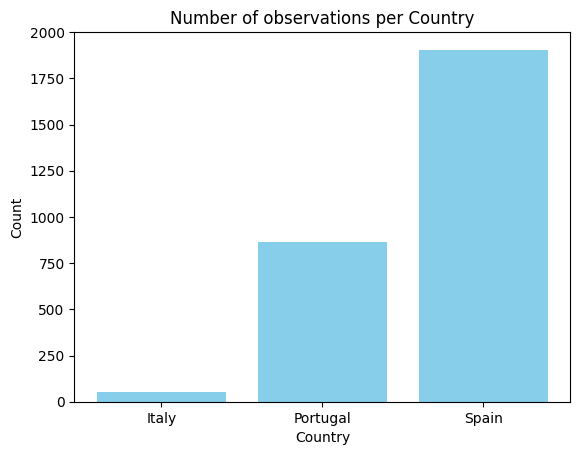

In [ ]:
# Using matplotlib
# Plot a bar chart using the country counts, setting the bar color to sky blue
plt.bar(country_count.index, country_count['count'], color='skyblue')

# Set the label for the x-axis
plt.xlabel('Country')

# Set the label for the y-axis
plt.ylabel('Count')

# Set the title of the plot
plt.title('Number of observations per Country')

# Display the plot on the screen
plt.show()

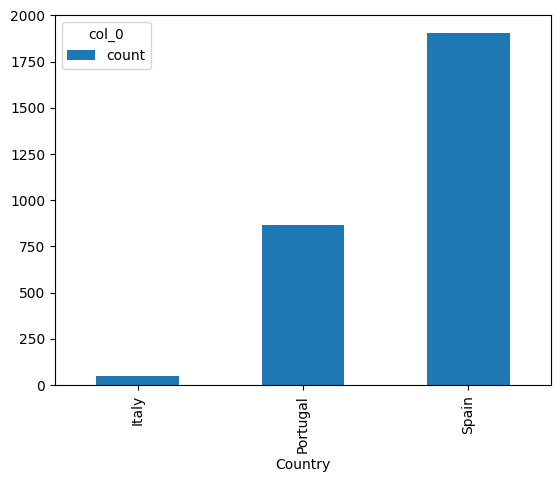

In [ ]:
# using pandas 'plot' method
country_count.plot(kind='bar')
plt.show()

In [ ]:
# getting help on the 'plot' method
help(country_count.plot)

Help on PlotAccessor in module pandas.plotting._core object:

class PlotAccessor(pandas.core.base.PandasObject)
 |  PlotAccessor(data: 'Series | DataFrame') -> 'None'
 |
 |  Make plots of Series or DataFrame.
 |
 |  Uses the backend specified by the
 |  option ``plotting.backend``. By default, matplotlib is used.
 |
 |  Parameters
 |  ----------
 |  data : Series or DataFrame
 |      The object for which the method is called.
 |  x : label or position, default None
 |      Only used if data is a DataFrame.
 |  y : label, position or list of label, positions, default None
 |      Allows plotting of one column versus another. Only used if data is a
 |      DataFrame.
 |  kind : str
 |      The kind of plot to produce:
 |
 |      - 'line' : line plot (default)
 |      - 'bar' : vertical bar plot
 |      - 'barh' : horizontal bar plot
 |      - 'hist' : histogram
 |      - 'box' : boxplot
 |      - 'kde' : Kernel Density Estimation plot
 |      - 'density' : same as 'kde'
 |      - 'area' 

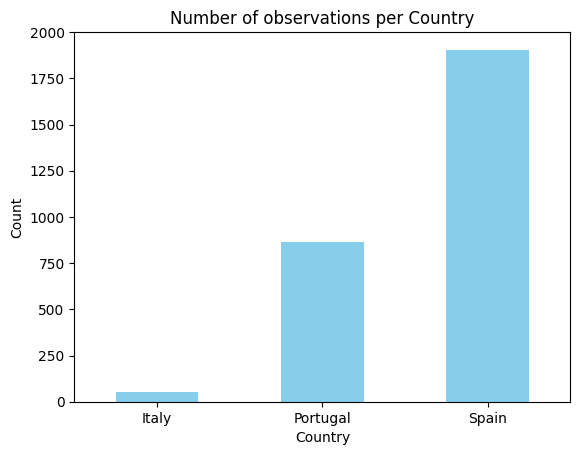

In [ ]:
# Fine tuning pandas 'plot' method
country_count.plot(kind='bar',
                   legend=False,
                   color='skyblue',
                   title='Number of observations per Country',
                   xlabel='Country',
                   ylabel='Count',
                   rot=0) # rot=0 - rotation of x labels
plt.show()

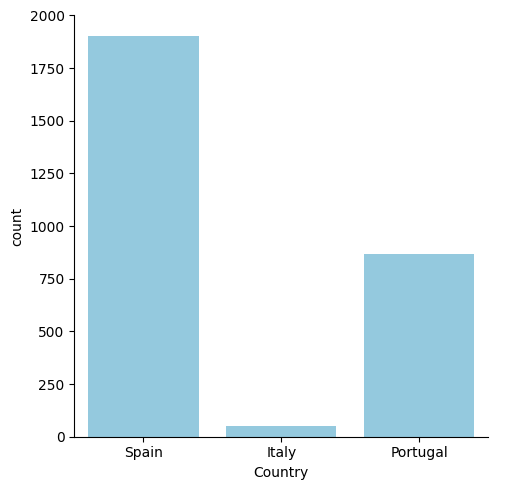

In [ ]:
# Now using seaborn
sns.catplot(x="Country", data=df2, kind="count", color="skyblue")
plt.show()

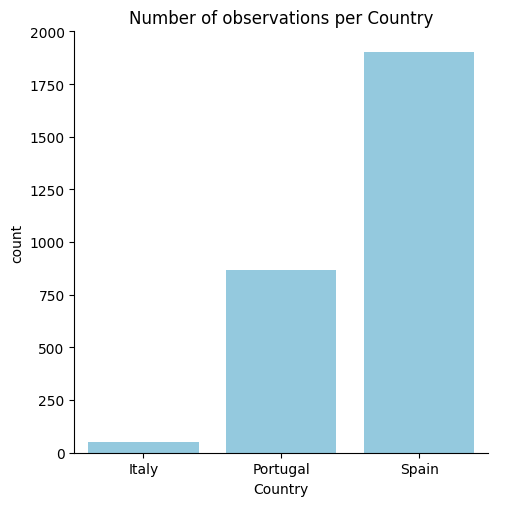

In [ ]:
# Same thing but now changing the order and including a title:
sns.catplot(x="Country", data=df2, kind="count", color="skyblue", order=['Italy', 'Portugal', 'Spain']).set(title='Number of observations per Country')
plt.show()

# Another way of including a title:
# ax = sns.catplot(x="Country", data=df, kind="count", color="skyblue", order=['Italy', 'Portugal', 'Spain'])
# ax.set_titles('Number of observations per Country')
# plt.show()

Plotting the number of sites per catchment

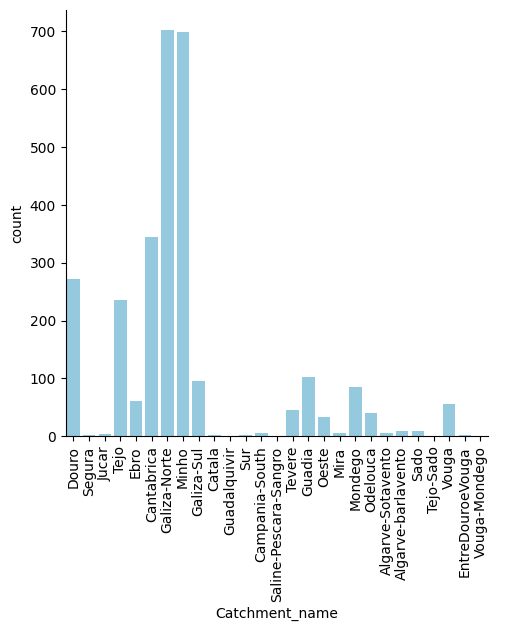

In [ ]:
# using Seaborn
sns.catplot(x="Catchment_name", data=df2, kind="count", color="skyblue")
plt.xticks(rotation=90)
plt.show()

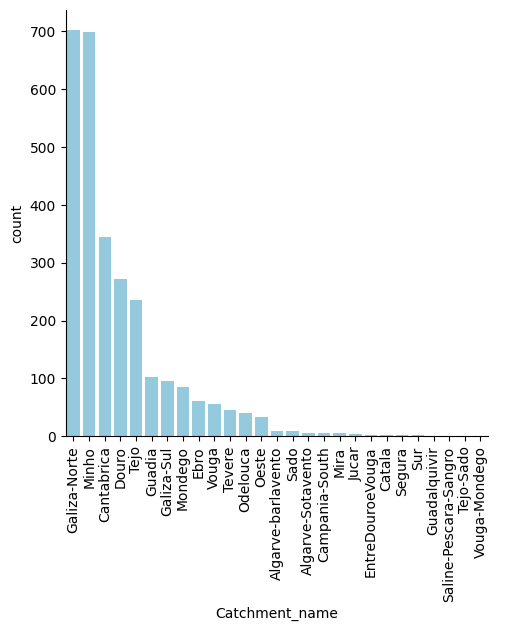

In [ ]:
# Same thing but in a decreasing order:
order = df2["Catchment_name"].value_counts().index # the order of the categories is defined by the number of observations (decreasing order)

sns.catplot(x="Catchment_name", data=df2, kind="count", color="skyblue", order=order)
plt.xticks(rotation=90)
plt.show()

##### Pie charts

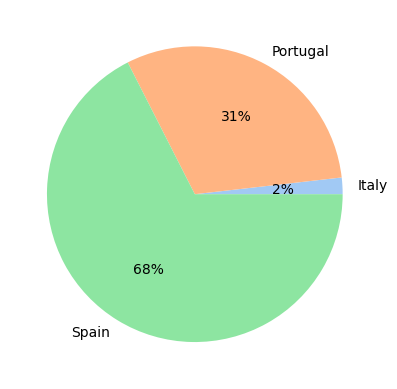

In [ ]:
# pie chart
colors = sns.color_palette('pastel')
labels = list(country_count.index) # list of country names
plt.pie(list(country_count.iloc[:,0]), labels=labels, colors = colors, autopct = '%0.0f%%')
plt.show()

##### Treemaps

To plot treemaps you'll need to install `squarify`: run `pip install squarify` in the terminal.

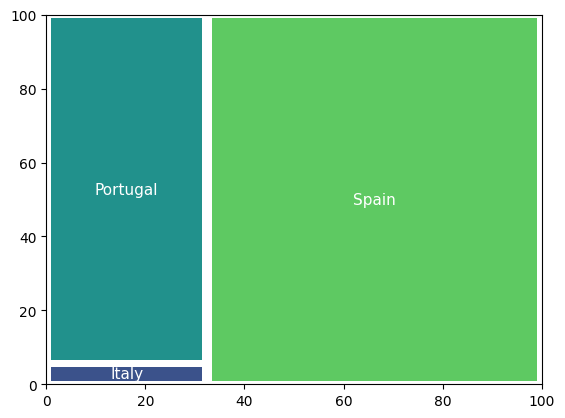

In [ ]:
!pip install squarify
import squarify as sqrf

labels = list(country_count.index) # list of country names

sqrf.plot(sizes=list(country_count.iloc[:,0]), # select all rows from the 1st column of data
          label=labels, # names of countries
          color=sns.color_palette('viridis',n_colors=len(labels)), # color palette
          text_kwargs={'fontsize': 11, 'color':"white"}, # label format
          pad=0.25) # define space between areas
plt.show()

### Plotting quantitative data

#### Strip plots
check here: https://seaborn.pydata.org/generated/seaborn.stripplot.html

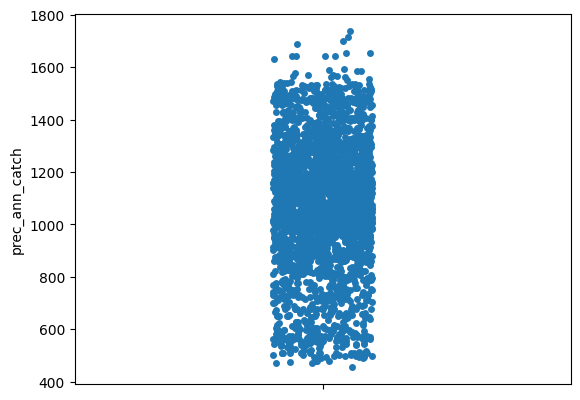

In [ ]:
# plot the mean annual total precipitation in the upstream catchment of each site
sns.stripplot(df2['prec_ann_catch'])
plt.show()


#### Histograms
check here: https://seaborn.pydata.org/generated/seaborn.histplot.html

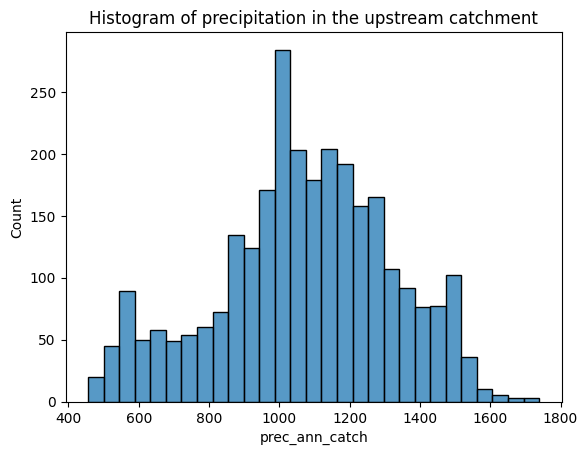

In [ ]:
# histogram of the mean annual total precipitation in the upstream catchment of each site
sns.histplot(df2['prec_ann_catch'], kde = False).set_title("Histogram of precipitation in the upstream catchment")
plt.show()

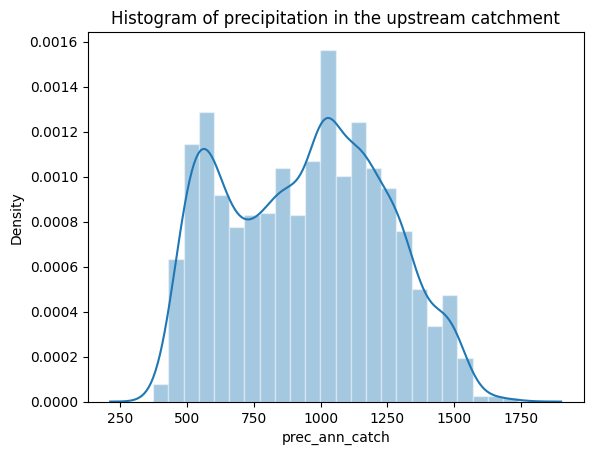

In [ ]:
# More variations
sns.histplot(
    df["prec_ann_catch"],
    kde=True,
    stat="density", # plot proportions instead of frequencies
    kde_kws=dict(cut=3),
    alpha=.4, # transparency
    edgecolor=(1, 1, 1, 0.4), # bar contour lines (r, g, b, alpha)
).set_title("Histogram of precipitation in the upstream catchment")
plt.show()

### Bar plots

Check here: https://seaborn.pydata.org/generated/seaborn.barplot.html

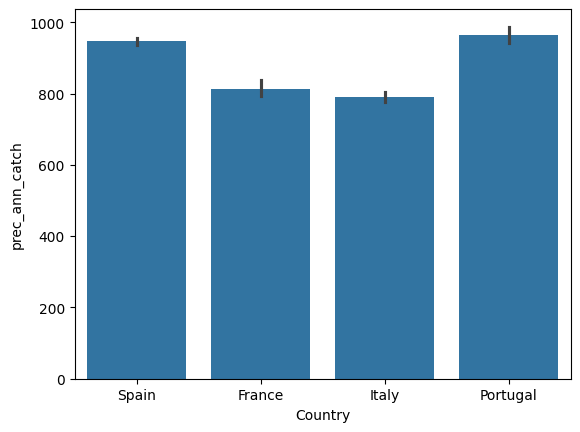

In [ ]:
# bar plot of Total Annual Precipitation by country
sns.barplot(x="Country", y="prec_ann_catch", data=df)
plt.show()

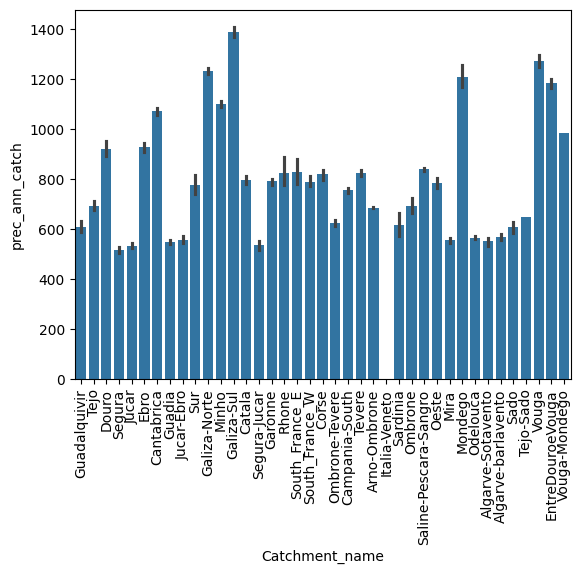

In [ ]:
# bar plot of Total Annual Precipitation by catchment
sns.barplot(data=df, x="Catchment_name", y="prec_ann_catch")
plt.xticks(rotation=90)
plt.show()

### Boxplots

Check here: https://seaborn.pydata.org/generated/seaborn.boxplot.html

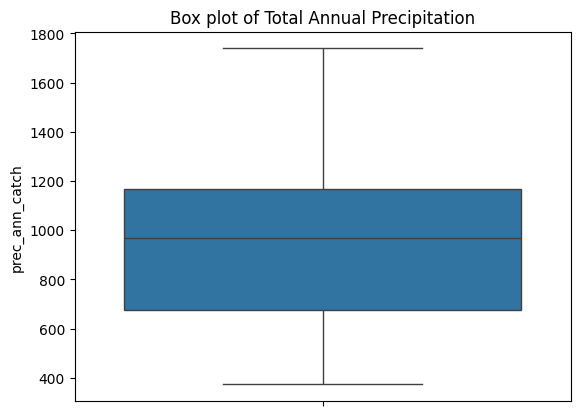

In [ ]:
# Box plot of Total Annual Precipitation
sns.boxplot(df["prec_ann_catch"]).set_title("Box plot of Total Annual Precipitation")
plt.show()

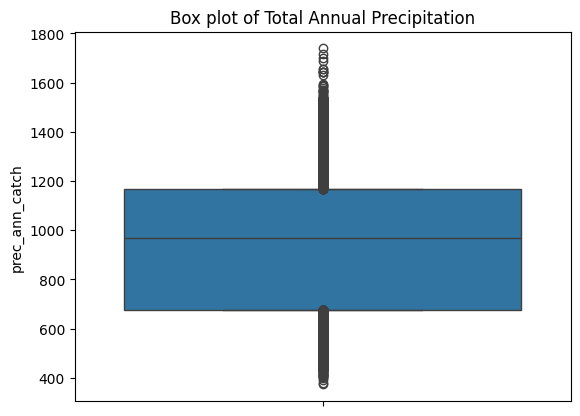

In [ ]:
# no whiskers (data points outside the box instead)
sns.boxplot(df["prec_ann_catch"], whis=0).set_title("Box plot of Total Annual Precipitation")
plt.show()

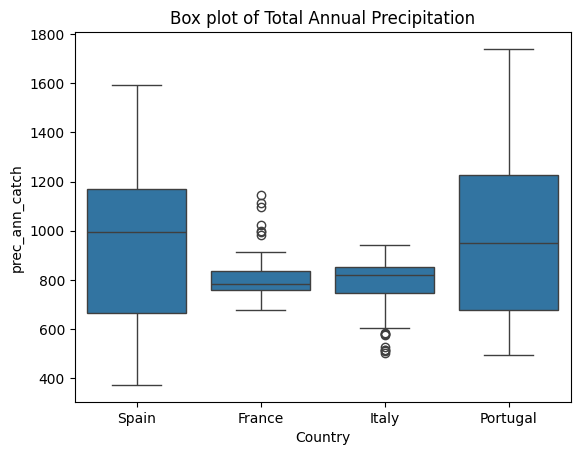

In [ ]:
# Box plot of Total Annual Precipitation by country
sns.boxplot(x="Country", y="prec_ann_catch", data=df).set_title("Box plot of Total Annual Precipitation")
plt.show()

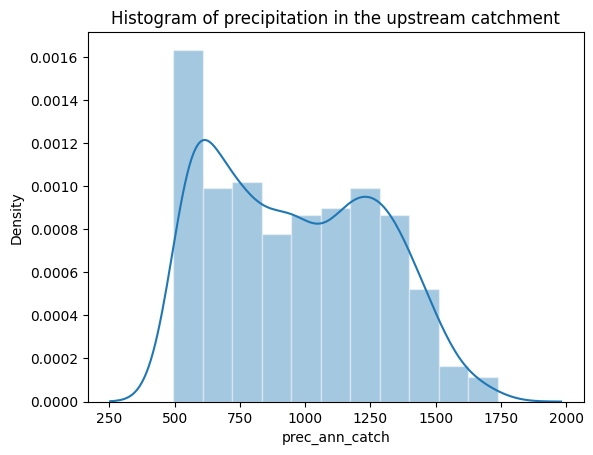

In [ ]:
# same thing but only for Portugal
df_port = df[df['Country']=='Portugal']

sns.histplot(
    df_port["prec_ann_catch"],
    kde=True,
    stat="density",
    kde_kws=dict(cut=3),
    alpha=.4,
    edgecolor=(1, 1, 1, 0.4),
).set_title("Histogram of precipitation in the upstream catchment")
plt.show()


### Violin plots

Check here: https://seaborn.pydata.org/generated/seaborn.violinplot.html

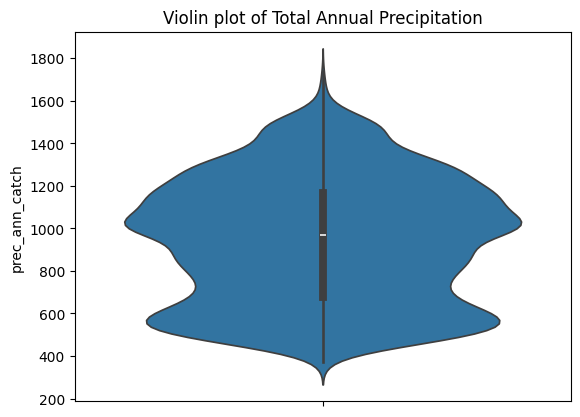

In [ ]:
# violin plot of Total Annual Precipitation by country
sns.violinplot(data=df, y="prec_ann_catch").set_title("Violin plot of Total Annual Precipitation")
plt.show()

### Raincloud plots

Raincloud plots combine violin plots, boxplots and strip plots into a single chart. To plot raincloud plots it is helpful to use the `ptitprince` library. You may need to install `ptitprince`by running `pip install ptitprince` in the terminal.

In [ ]:
try:
    import ptitprince as pt
except ImportError:
    !pip install ptitprince
    import ptitprince as pt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 37.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for ptitprince: filename=ptitprince-0.3.1-py3-none-any.whl size=16216 sha256=105e89d267ea4866ff12c3c7e3b95bca15e958ab1ca298b61b4ed06251882ae4
  Stored in directory: /root/.cache/pip/wheels/5d/79/49/b89a41fd3d8780ce2c21c7f2debe45f3c6b08d8aef400e3df1
Successfully built ptitprince


In [ ]:
help(pt.RainCloud)

Help on function RainCloud in module ptitprince.PtitPrince:

RainCloud(x: Union[pandas.core.series.Series, numpy.ndarray, list, NoneType] = None, y: Union[pandas.core.series.Series, numpy.ndarray, list, NoneType] = None, hue: Union[pandas.core.series.Series, numpy.ndarray, list, NoneType] = None, data: Optional[pandas.core.frame.DataFrame] = None, order: Optional[list[str]] = None, hue_order: Optional[list[str]] = None, orient: str = 'v', width_viol: float = 0.7, width_box: float = 0.15, palette: Union[str, list, dict, NoneType] = None, bw: Union[str, float] = 0.2, linewidth: float = 1, cut: float = 0.0, scale: str = 'area', jitter: bool = True, move: float = 0.0, offset: Optional[float] = None, point_size: float = 3, ax: Optional[matplotlib.axes._axes.Axes] = None, pointplot: bool = False, alpha: Optional[float] = None, dodge: bool = False, linecolor: str = 'red', **kwargs: Any) -> matplotlib.axes._axes.Axes
    Draw a Raincloud plot of measure `y` of different categories `x`.

    He

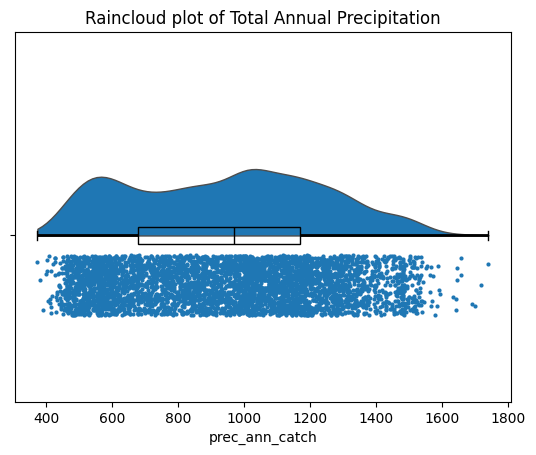

In [ ]:
# Raincloud plot of Total Annual Precipitation

pt.RainCloud(y="prec_ann_catch", data=df,
             bw=0.2, # defines how smooth is the distribution curve of the violin plot (cloud)
             width_viol=0.4, # width of the half violin (cloud)
             width_box=0.05, # width of the box
             orient='h', # orientation
             move=0.15, # position of the strip plot
             offset=0,# relative position of the half violin (cloud) in relation to the boxplot
             jitter=0.09) # allows to define the width of the strip plot (rain)

plt.title("Raincloud plot of Total Annual Precipitation")
plt.show()

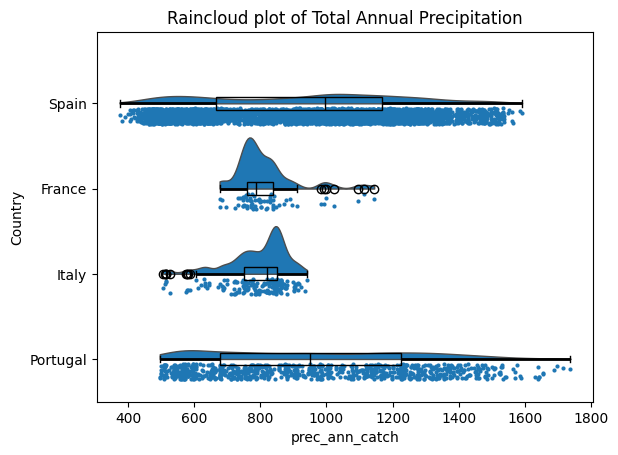

In [ ]:
# Raincloud plot of Total Annual Precipitation by country

pt.RainCloud(x='Country', y="prec_ann_catch", data=df,
             bw=0.2, # defines how smooth is the distribution curve of the violin plot (cloud)
             width_viol=1.2, # width of the half violin (cloud)
             width_box=0.15, # wdth of the box
             orient='h', # orientation
             move=0.15, #position of the strip plot
             offset=0,# relative position of the half violin (cloud) in relation to the boxplot
             jitter=0.09) # allows to define the width of the strip plot (rain)

plt.title("Raincloud plot of Total Annual Precipitation")
plt.show()

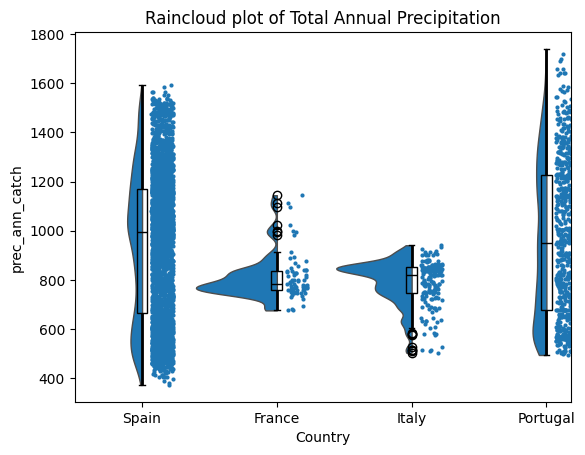

In [ ]:
# Vertical raincloud plot of Total Annual Precipitation by country

pt.RainCloud(x='Country', y="prec_ann_catch", data=df,
             bw=0.2, # defines how smooth is the distribution curve of the violin plot (cloud)
             width_viol=1.2, # width of the half violin (cloud)
             width_box=0.08, # wdth of the box
             move=0.15, #position of the strip plot
             offset=0,# relative position of the half violin (cloud) in relation to the boxplot
             jitter=0.08) # allows to define the width of the strip plot (rain)

plt.title("Raincloud plot of Total Annual Precipitation")
plt.show()

#EXERCISE 3

In [ ]:
# TOPIC 1
#Identify the top 4 catchments with the highest number of fish sampling sites

top_4_catchments = df2['Catchment_name'].value_counts().head(4).index.tolist()
print(f"Top 4 Catchments: {top_4_catchments}")

# Filter the DataFrame to include only these top 4 catchments
filtered_df_top_catchments = df2[df2['Catchment_name'].isin(top_4_catchments)].copy()

Top 4 Catchments: ['Galiza-Norte', 'Minho', 'Cantabrica', 'Douro']


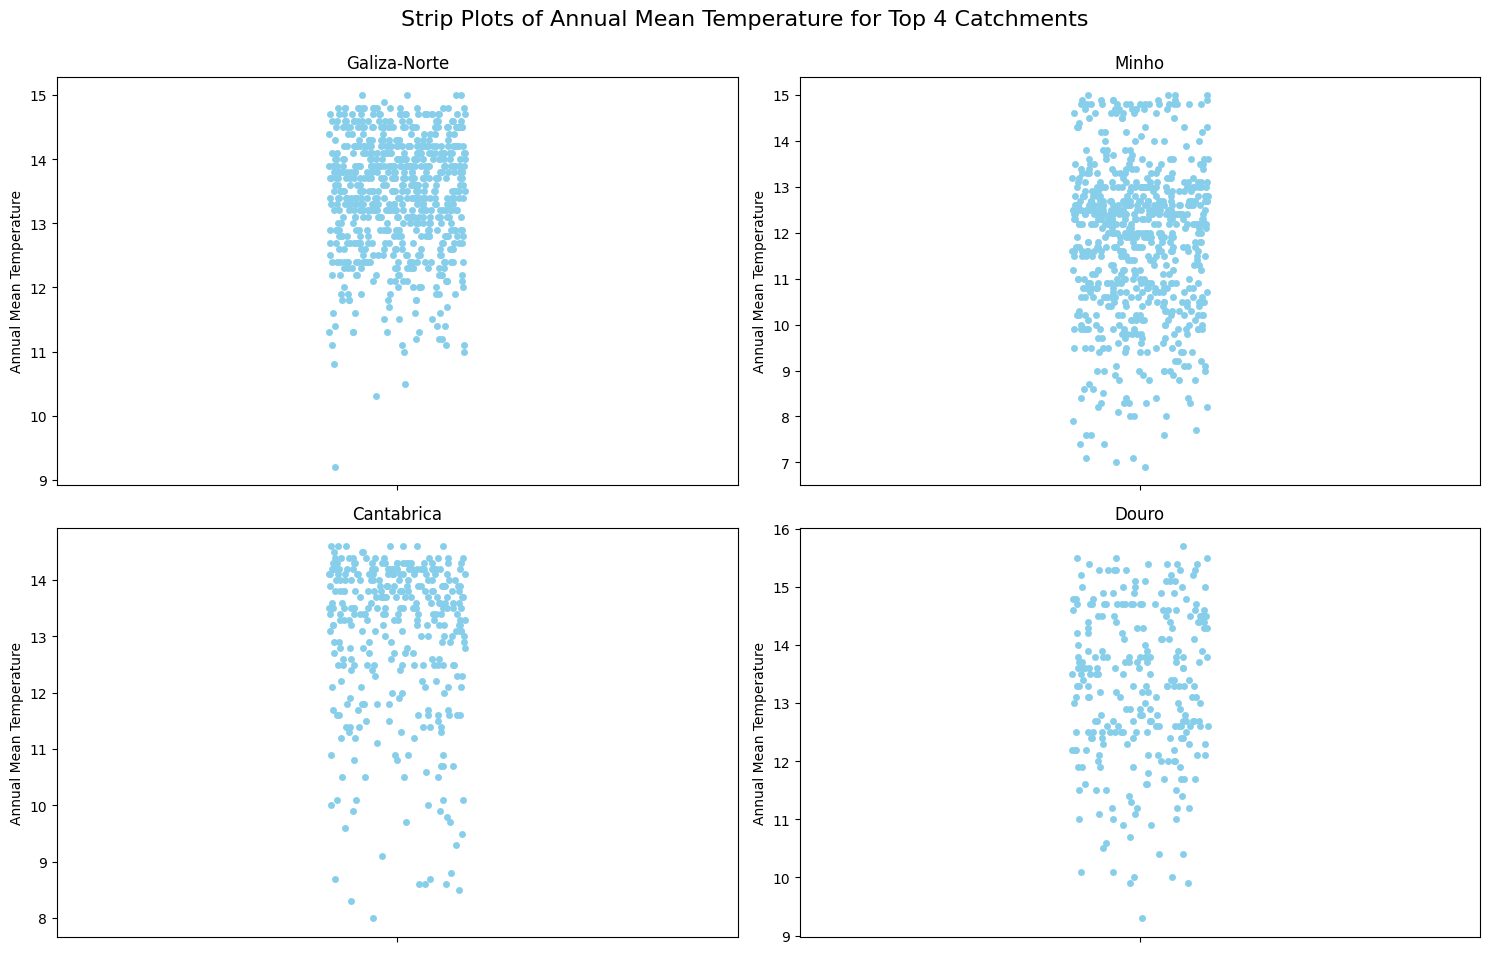

In [ ]:
# Strip Plots of Annual Mean Temperature for Top 4 Catchments

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, catchment in enumerate(top_4_catchments):
    sns.stripplot(y=filtered_df_top_catchments[filtered_df_top_catchments['Catchment_name'] == catchment]['temp_ann'], ax=axes[i], color='skyblue')
    axes[i].set_title(f'{catchment}')
    axes[i].set_ylabel('Annual Mean Temperature')
    axes[i].set_xlabel('')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.suptitle('Strip Plots of Annual Mean Temperature for Top 4 Catchments', fontsize=16)
plt.show()

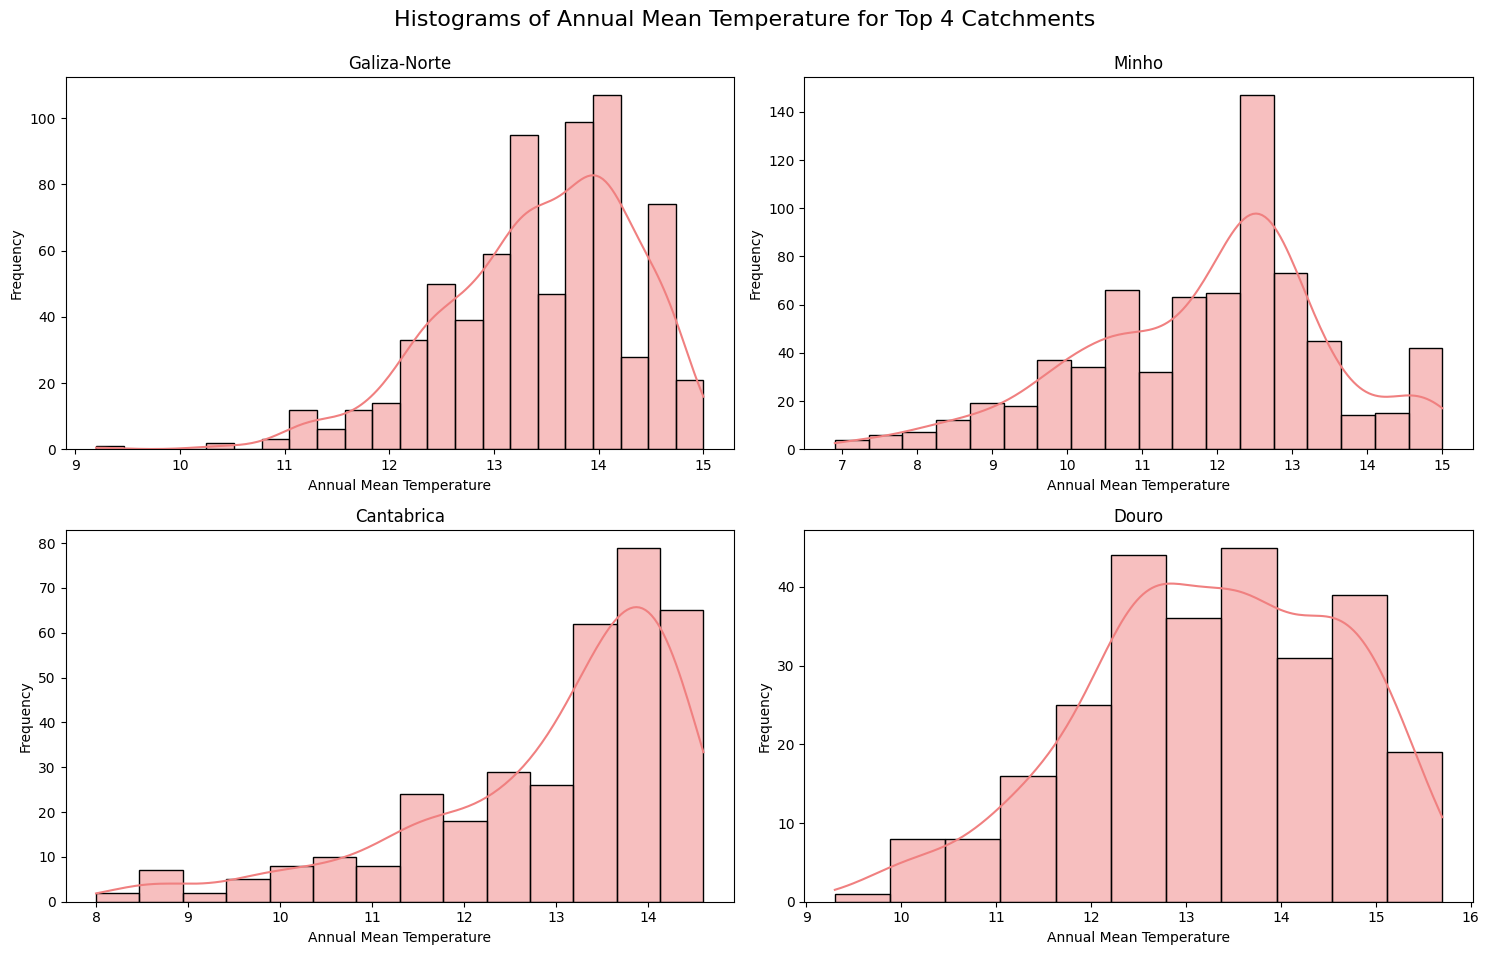

In [ ]:
# Histograms of Annual Mean Temperature for Top 4 Catchments

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, catchment in enumerate(top_4_catchments):
    sns.histplot(filtered_df_top_catchments[filtered_df_top_catchments['Catchment_name'] == catchment]['temp_ann'], kde=True, ax=axes[i], color='lightcoral')
    axes[i].set_title(f'{catchment}')
    axes[i].set_xlabel('Annual Mean Temperature')
    axes[i].set_ylabel('Frequency')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.suptitle('Histograms of Annual Mean Temperature for Top 4 Catchments', fontsize=16)
plt.show()

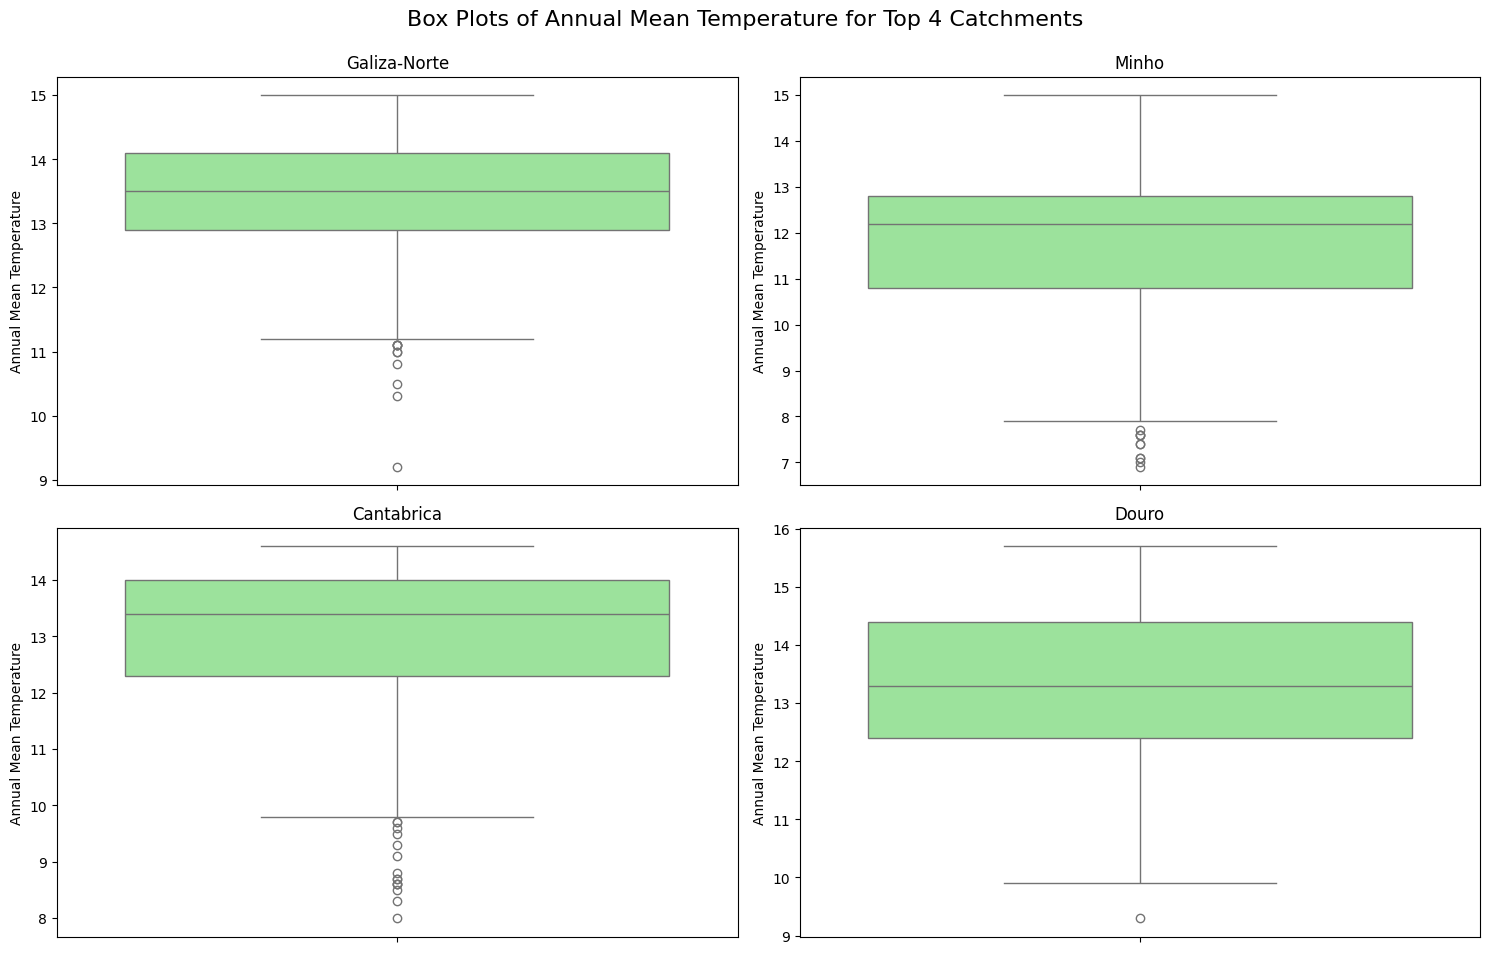

In [ ]:
# Box Plots of Annual Mean Temperature for Top 4 Catchments

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, catchment in enumerate(top_4_catchments):
    sns.boxplot(y=filtered_df_top_catchments[filtered_df_top_catchments['Catchment_name'] == catchment]['temp_ann'], ax=axes[i], color='lightgreen')
    axes[i].set_title(f'{catchment}')
    axes[i].set_ylabel('Annual Mean Temperature')
    axes[i].set_xlabel('')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.suptitle('Box Plots of Annual Mean Temperature for Top 4 Catchments', fontsize=16)
plt.show()

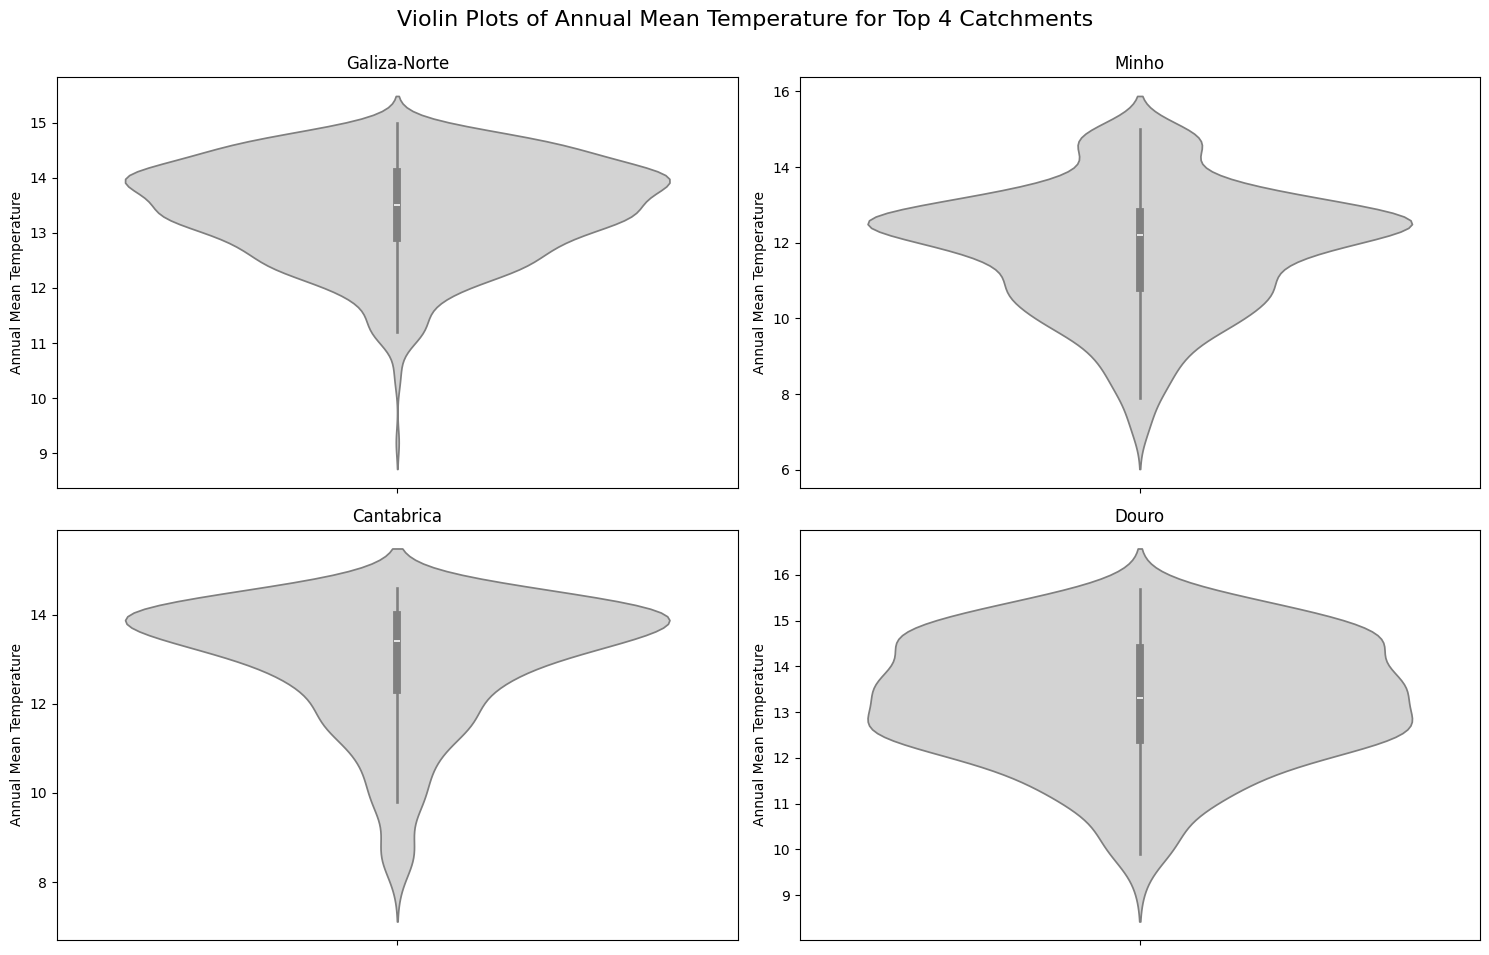

In [ ]:
# Violin Plots of Annual Mean Temperature for Top 4 Catchments (Additional Plot)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, catchment in enumerate(top_4_catchments):
    sns.violinplot(y=filtered_df_top_catchments[filtered_df_top_catchments['Catchment_name'] == catchment]['temp_ann'], ax=axes[i], color='lightgray')
    axes[i].set_title(f'{catchment}')
    axes[i].set_ylabel('Annual Mean Temperature')
    axes[i].set_xlabel('')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.suptitle('Violin Plots of Annual Mean Temperature for Top 4 Catchments', fontsize=16)
plt.show()

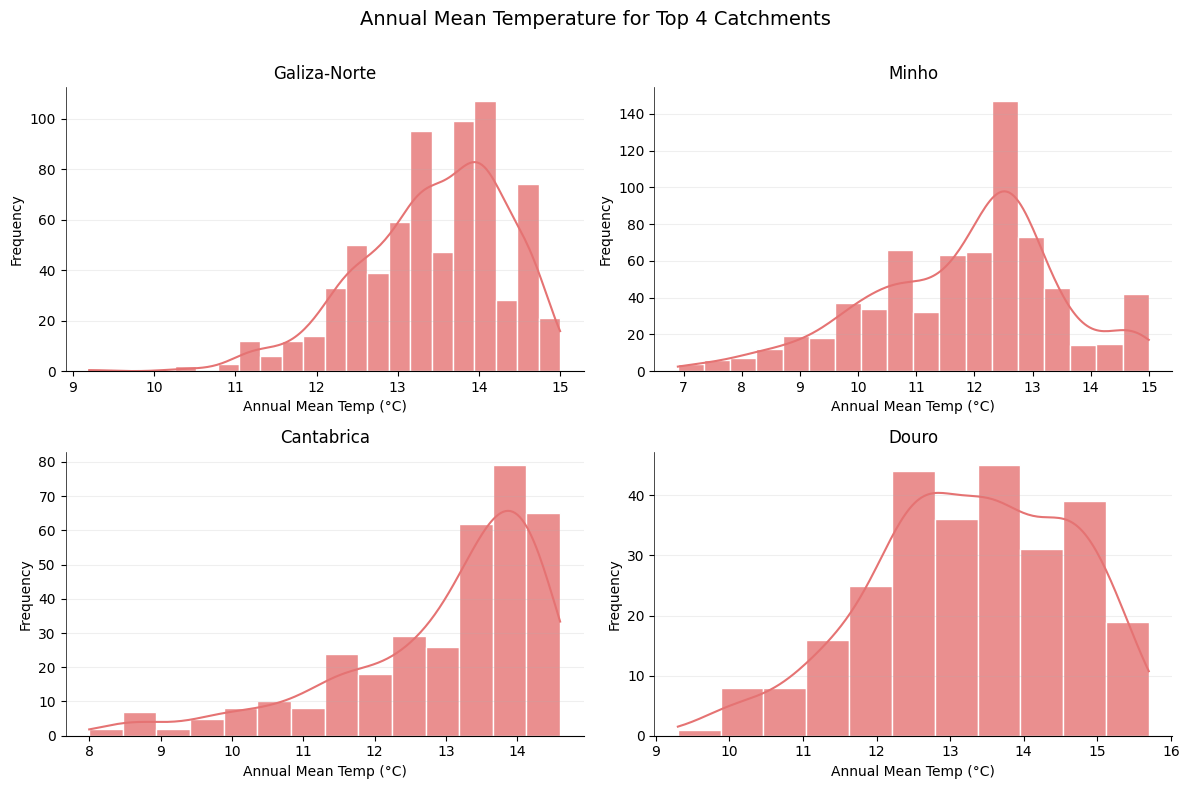

In [ ]:
# TOPIC 2
#Following Lesson 2 principles to improve the data visualization:

fig, axes = plt.subplots(2, 2, figsize=(12, 8))  # REDUCED SIZE
# Convert the numpy array of axes into a flat list of axes objects
axes = axes.ravel().tolist() # Converting to a Python list

for i, catchment in enumerate(top_4_catchments):
    data = filtered_df_top_catchments[filtered_df_top_catchments['Catchment_name'] == catchment]['temp_ann']

    # BEST PRACTICES IMPLEMENTED:
    # Explicitly pass 'data' to 'x' parameter to avoid potential ambiguity with 'ax'
    sns.histplot(x=data, kde=True, ax=axes[i], color='#E57373', edgecolor='white', alpha=0.8)
    axes[i].set_title(catchment, fontsize=12)  # SHORT TITLES
    axes[i].set_xlabel('Annual Mean Temp (°C)')  # CLEAR UNITS
    axes[i].set_ylabel('Frequency')

    # DATA-INK MAXIMIZATION:
    axes[i].spines['top'].set_visible(False)      # NO TOP FRAME
    axes[i].spines['right'].set_visible(False)    # NO RIGHT FRAME
    axes[i].spines['left'].set_linewidth(0.5)     # THIN AXIS ONLY
    axes[i].grid(axis='y', alpha=0.2)             # LIGHT GRID ONLY

plt.suptitle('Annual Mean Temperature for Top 4 Catchments\n', fontsize=14)
plt.tight_layout()
plt.show()

#EXERCISE 3

TOPIC 3

Evaluate the pros and cons of each type as univariate visualizations:

1. STRIPPLOT

PROS: Raw data points show all observations without aggregation bias; excellent for outlier detection; truthful representation (Lesson 2: show data variability)

CONS: Overplotting creates chart junk with many points; no density/shape information; jitter distorts true positions (Lesson 2: graphical integrity violation)
Best for: Small datasets (N<50 per catchment)

2. HISTOGRAM

PROS: Reveals complete distribution shape including multimodality; high data-ink ratio when cleaned; universal familiarity

CONS: Subjective binning changes perception; difficult side-by-side comparison across catchments

Best for: Understanding distribution characteristics

3. BOXPLOT

PROS: 5-number summary + outliers; perfect for small multiples comparing 4 catchments; minimal ink maximum insight

CONS: Hides shape/multimodality details

Best for: Scientific catchment temperature comparison

4. VIOLINPLOT

PROS: Combines density estimation + quartiles; reveals distribution shape

CONS: Visual complexity causes viewer overload; width comparison difficult across panels

Best for: Complex distributions needing shape + summary

# FINAL RECOMMENDATION:

Boxplot is optimal for academic/scientific catchment comparison:

*   Small multiples friendly
*   Honest variability (IQR+outliers)
*   Minimal chart junk
*   Academic visualization wheel sweet spot



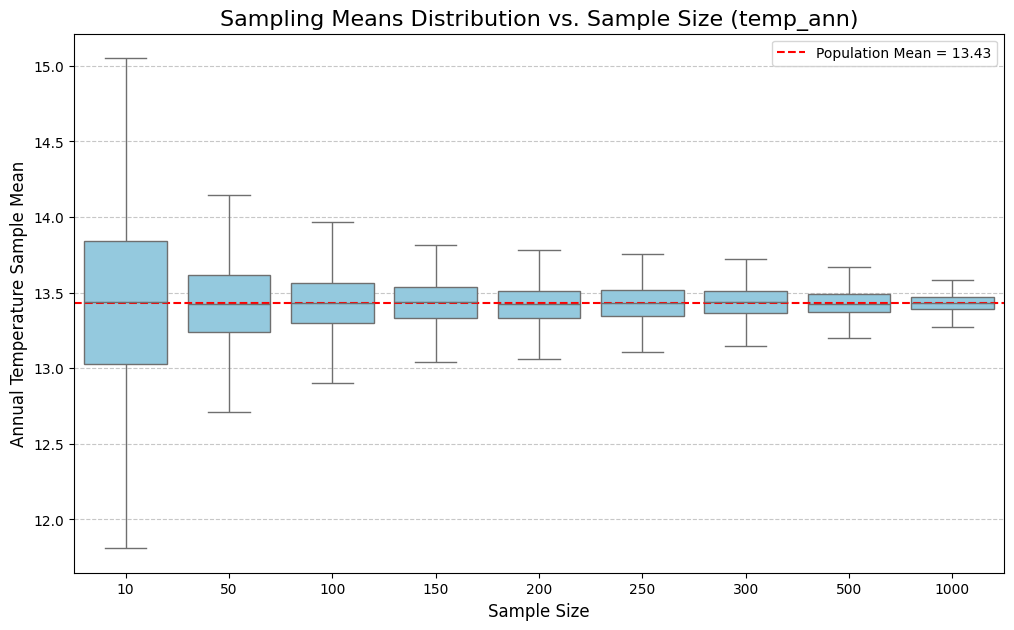

In [ ]:
#How the mean value of temp_annvaries with the size of random samplings of sites:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define the sample sizes to test
sample_sizes = [10, 50, 100, 150, 200, 250, 300, 500, 1000]
num_simulations = 1000

# Get the true population mean for comparison
population_mean = df2['temp_ann'].mean()

# List to store results
all_sample_means = []

# Perform the simulation
for size in sample_sizes:
    for _ in range(num_simulations):
        # Take a random sample with replacement
        sample = df2['temp_ann'].sample(n=size, replace=True)
        # Calculate the mean of the sample
        sample_mean = sample.mean()
        all_sample_means.append({'sample_size': size, 'sample_mean': sample_mean})

# Convert results to a DataFrame
sample_means_df = pd.DataFrame(all_sample_means)

# Plotting the results
plt.figure(figsize=(12, 7))
sns.boxplot(x='sample_size', y='sample_mean', data=sample_means_df, color='skyblue', showfliers=False)

# Add a line for the true population mean
plt.axhline(y=population_mean, color='red', linestyle='--', label=f'Population Mean = {population_mean:.2f}')

plt.title('Sampling Means Distribution vs. Sample Size (temp_ann)', fontsize=16)
plt.xlabel('Sample Size', fontsize=12)
plt.ylabel('Annual Temperature Sample Mean', fontsize=12)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


### EXERCISE 4

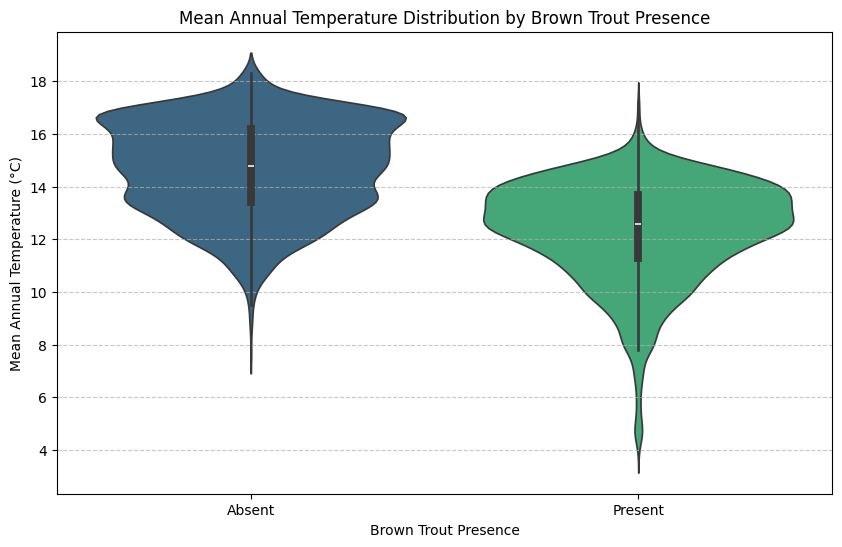

In [ ]:
# TOPIC 1: Using an appropriate visualization, explore how Mean Annual Temperature (Temp_ann) may affect the presence of Salmo truttafario (Brown Trout).

# Violin Plot: Brown Trout Presence vs. Mean Annual Temperature

plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x="Trout_presence", y="temp_ann", hue="Trout_presence", palette="viridis", legend=False)
plt.xticks([0, 1], ["Absent", "Present"])
plt.xlabel("Brown Trout Presence")
plt.ylabel("Mean Annual Temperature (°C)")
plt.title("Mean Annual Temperature Distribution by Brown Trout Presence")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

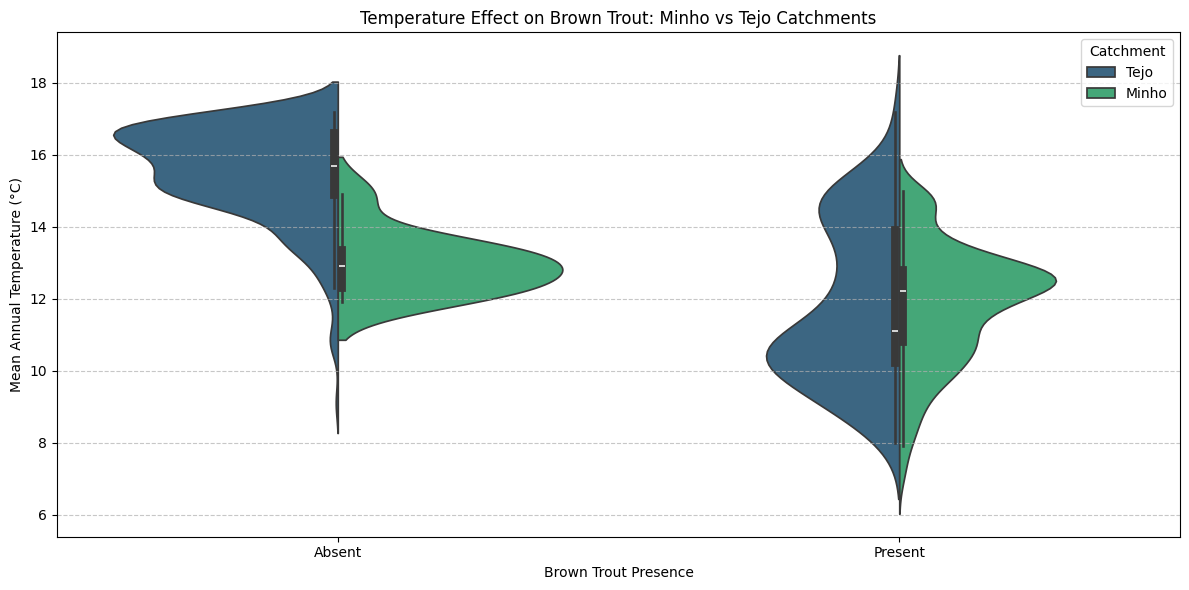

Trout_presence     0     1  Effect Size (°C)
Catchment_name                              
Minho           12.9  12.2              -0.7
Tejo            15.7  11.1              -4.6


In [ ]:
# TOPIC 2: Check the same effect but now separately for Minho and Tagus catchments and comparing the “effect sizes”.

# Filter for Minho and Tagus catchments
df_filtered = df[df['Catchment_name'].isin(['Minho', 'Tejo'])].copy()
df_filtered["Trout_presence"] = (df_filtered["Salmo trutta fario"] > 0).astype(int)

plt.figure(figsize=(12, 6))
sns.violinplot(data=df_filtered, x="Trout_presence", y="temp_ann",
               hue="Catchment_name", palette="viridis", split=True)
plt.xticks([0, 1], ["Absent", "Present"])
plt.xlabel("Brown Trout Presence")
plt.ylabel("Mean Annual Temperature (°C)")
plt.title("Temperature Effect on Brown Trout: Minho vs Tejo Catchments")
plt.legend(title="Catchment")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Calculate effect sizes (median temperature difference)
effect_sizes = df_filtered.groupby(['Catchment_name', 'Trout_presence'])['temp_ann'].median().unstack()
effect_sizes['Effect Size (°C)'] = effect_sizes[1] - effect_sizes[0]
print(effect_sizes.round(2))

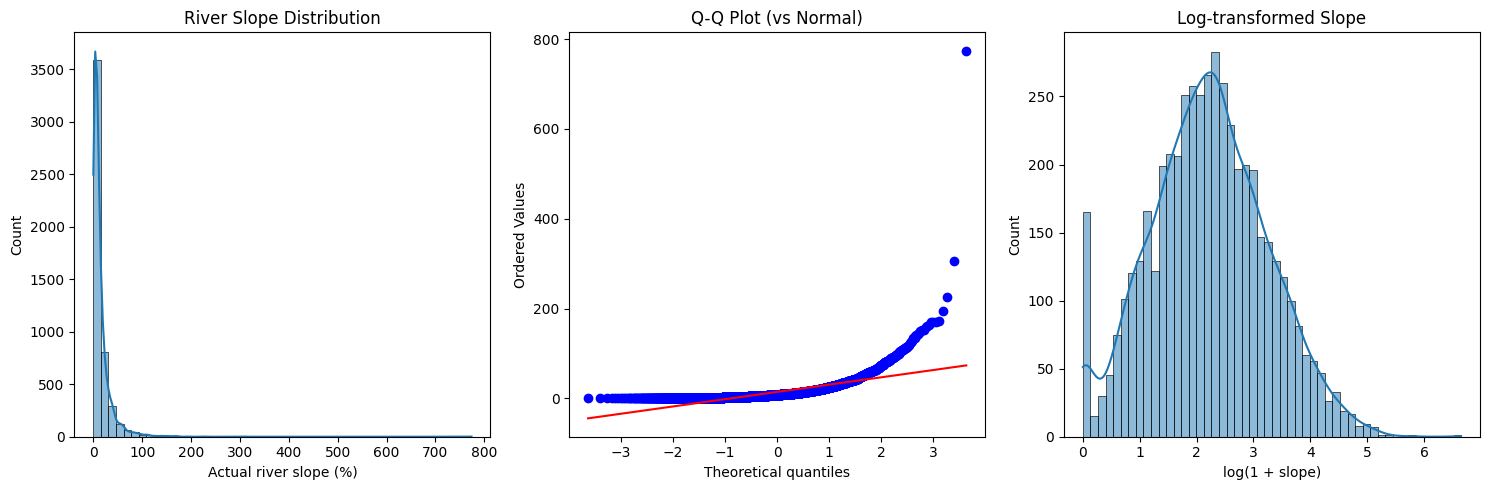

Shapiro-Wilk Test Statistic: 0.516
P-value: 0.000

Based on the p-value, we reject the null hypothesis.
'Actual_river_slope' does not appear to be normally distributed.


In [ ]:
# TOPIC 3: Test, using both visualization and hypothesis testing methods, if the actual_river_slopeis drawn from a normal distribution.

import scipy.stats as stats # Import the scipy.stats module

plt.figure(figsize=(15, 5))

# Left: Histogram
plt.subplot(1, 3, 1)
sns.histplot(df['Actual_river_slope'], bins=50, kde=True)
plt.title("River Slope Distribution")
plt.xlabel("Actual river slope (%)")

# Middle: Q-Q plot
plt.subplot(1, 3, 2)
stats.probplot(df['Actual_river_slope'].dropna(), dist="norm", plot=plt)
plt.title("Q-Q Plot (vs Normal)")

# Right: Log-transformed
plt.subplot(1, 3, 3)
log_slope = np.log1p(df['Actual_river_slope'].dropna())
sns.histplot(log_slope, bins=50, kde=True)
plt.title("Log-transformed Slope")
plt.xlabel("log(1 + slope)")

plt.tight_layout()
plt.show()

# Performing the Shapiro-Wilk test for the 'Actual_river_slope' variable.
# It is important to remove NaN values before the test.
shapiro_test = stats.shapiro(df['Actual_river_slope'].dropna())

print(f"Shapiro-Wilk Test Statistic: {shapiro_test.statistic:.3f}")
print(f"P-value: {shapiro_test.pvalue:.3f}")

# Interpretation of the result
alpha = 0.05 # Common significance level
if shapiro_test.pvalue > alpha:
    print("\nBased on the p-value, we do not reject the null hypothesis.")
    print("'Actual_river_slope' appears to be normally distributed (or there is not enough evidence to the contrary).")
else:
    print("\nBased on the p-value, we reject the null hypothesis.")
    print("'Actual_river_slope' does not appear to be normally distributed.")

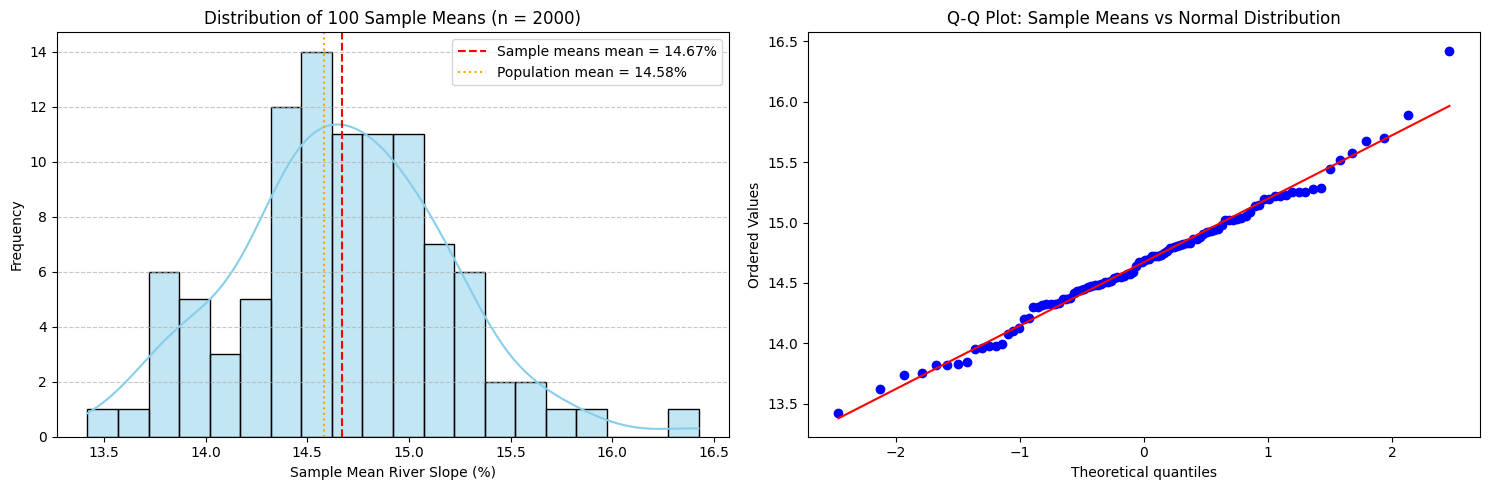

Sample Means Analysis Results:
Mean of 100 sample means:   14.672%
Standard error of means:             0.521%
Population mean (original data):     14.582%

Shapiro-Wilk Normality Test:
Test statistic: 0.989
P-value:        0.5859

Result: p = 0.5859 > 0.05
Conclusion: Cannot reject normality hypothesis
Sample means follow normal distribution

------------------------------------------------------------
CENTRAL LIMIT THEOREM VALIDATED
Original data highly skewed  →  Sample means normally distributed
Justifies parametric tests for mean comparisons in ecology
------------------------------------------------------------


In [ ]:
# TOPIC 4: Take 100 samples of 2000 observations WITH replacement,
# compute means, plot histogram, test normality of means

# Extract the 'Actual_river_slope' variable and remove NaNs
slope_data = pd.to_numeric(df['Actual_river_slope'], errors='coerce').dropna()

# Parameters for the simulation
num_samples = 100
sample_size = 2000

# List to store the means of each sample
sample_means = []

# Perform the simulation: 100 bootstrap samples WITH REPLACEMENT
for _ in range(num_samples):
    sample = slope_data.sample(n=sample_size, replace=True)
    sample_means.append(sample.mean())

sample_means_series = pd.Series(sample_means)

# Professional side-by-side visualization
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
sns.histplot(sample_means_series, kde=True, bins=20, color='skyblue', edgecolor='black')
plt.axvline(sample_means_series.mean(), color='red', linestyle='--',
           label=f'Sample means mean = {sample_means_series.mean():.2f}%')
plt.axvline(slope_data.mean(), color='orange', linestyle=':',
           label=f'Population mean = {slope_data.mean():.2f}%')
plt.title(f'Distribution of {num_samples} Sample Means (n = {sample_size})')
plt.xlabel('Sample Mean River Slope (%)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.subplot(1, 2, 2)
stats.probplot(sample_means_series, dist="norm", plot=plt)
plt.title('Q-Q Plot: Sample Means vs Normal Distribution')

plt.tight_layout()
plt.show()

# Shapiro-Wilk test results
shapiro_test = stats.shapiro(sample_means_series)

print("Sample Means Analysis Results:")
print(f"Mean of {num_samples} sample means:   {sample_means_series.mean():.3f}%")
print(f"Standard error of means:             {sample_means_series.std():.3f}%")
print(f"Population mean (original data):     {slope_data.mean():.3f}%")
print()
print("Shapiro-Wilk Normality Test:")
print(f"Test statistic: {shapiro_test.statistic:.3f}")
print(f"P-value:        {shapiro_test.pvalue:.4f}")

alpha = 0.05
if shapiro_test.pvalue > alpha:
    print(f"\nResult: p = {shapiro_test.pvalue:.4f} > 0.05")
    print("Conclusion: Cannot reject normality hypothesis")
    print("Sample means follow normal distribution")
else:
    print(f"\nResult: p = {shapiro_test.pvalue:.4f} < 0.05")
    print("Conclusion: Reject normality hypothesis")

print("\n" + 60*"-")
print("CENTRAL LIMIT THEOREM VALIDATED")
print("Original data highly skewed  →  Sample means normally distributed")
print("Justifies parametric tests for mean comparisons in ecology")
print(60*"-")
